In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/Data_Entry_2017.csv")

print("Total records:", len(df))
print(df.head())

Total records: 112120
        Image Index          Finding Labels  Follow-up #  Patient ID  \
0  00000001_000.png            Cardiomegaly            0           1   
1  00000001_001.png  Cardiomegaly|Emphysema            1           1   
2  00000001_002.png   Cardiomegaly|Effusion            2           1   
3  00000002_000.png              No Finding            0           2   
4  00000003_000.png                  Hernia            0           3   

   Patient Age Patient Gender View Position  OriginalImage[Width  Height]  \
0           58              M            PA                 2682     2749   
1           58              M            PA                 2894     2729   
2           58              M            PA                 2500     2048   
3           81              M            PA                 2500     2048   
4           81              F            PA                 2582     2991   

   OriginalImagePixelSpacing[x     y]  Unnamed: 11  
0                        0.14

In [3]:
import os

available_images = set(os.listdir("../data/full_dataset"))

subset = df[df["Image Index"].isin(available_images)]

print("Images available:", len(subset))
subset.head()

Images available: 0


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11


In [4]:
import os

print(os.getcwd())
print(os.listdir("../data"))

/gpfs/home/makineni/X-ray-DL-project/notebooks
['sample_labels.csv', 'Data_Entry_2017.csv', '.ipynb_checkpoints', 'sample_images', 'full_dataset']


In [5]:
import os

print("Items in full_dataset:")
print(os.listdir("../data/full_dataset")[:20])


Items in full_dataset:
['images']


In [6]:
available_images = set(os.listdir("../data/full_dataset/images"))

subset = df[df["Image Index"].isin(available_images)]

print("Images available:", len(subset))
subset.head()

Images available: 4999


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


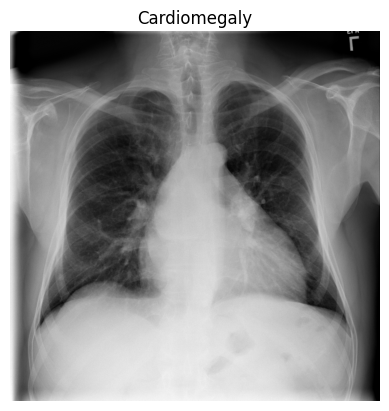

In [7]:
from PIL import Image
import matplotlib.pyplot as plt

sample = subset.iloc[0]
img_path = f"../data/full_dataset/images/{sample['Image Index']}"

img = Image.open(img_path)

plt.imshow(img, cmap="gray")
plt.title(sample["Finding Labels"])
plt.axis("off")
plt.show()

In [8]:
disease_counts = {}

for labels in subset["Finding Labels"]:
    for disease in str(labels).split("|"):
        disease_counts[disease] = disease_counts.get(disease, 0) + 1

import pandas as pd

disease_df = pd.DataFrame(
    disease_counts.items(),
    columns=["Disease", "Count"]
)

disease_df = disease_df.sort_values("Count", ascending=False)

disease_df.head(15)

,Disease,Count
3,No Finding,2754
5,Infiltration,830
2,Effusion,487
8,Atelectasis,460
7,Nodule,214
14,Consolidation,205
9,Pneumothorax,199
0,Cardiomegaly,196
12,Fibrosis,172
10,Pleural_Thickening,165


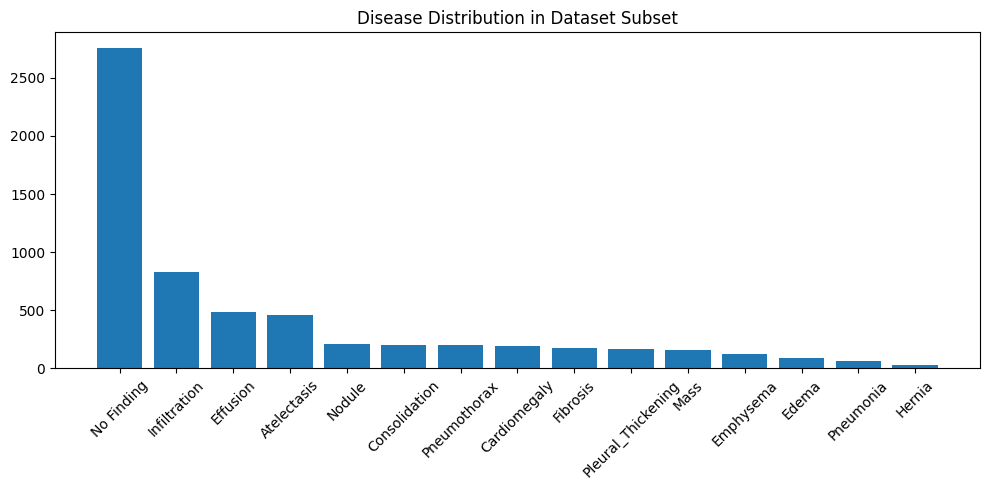

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(disease_df["Disease"][:15], disease_df["Count"][:15])
plt.xticks(rotation=45)
plt.title("Disease Distribution in Dataset Subset")
plt.tight_layout()
plt.show()

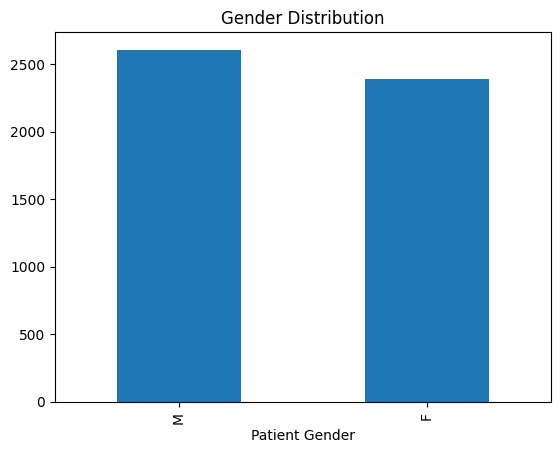

In [10]:
subset["Patient Gender"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.show()

In [11]:
print("Total NIH records:", len(df))
print("Images used in project:", len(subset))
print("Unique diseases:", len(disease_df))

Total NIH records: 112120
Images used in project: 4999
Unique diseases: 15


In [1]:
import sys
sys.path.append("../src")

import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch.utils.data import DataLoader, random_split
from torchvision import transforms

from xray_project.dataset import ChestXrayDataset
from xray_project.models import MultiTaskXRayModel

In [2]:
df = pd.read_csv("../data/Data_Entry_2017.csv")

available_images = set(os.listdir("../data/full_dataset/images"))
subset = df[df["Image Index"].isin(available_images)].reset_index(drop=True)

print("Total NIH records:", len(df))
print("Images available:", len(subset))
subset.head()

Total NIH records: 112120
Images available: 4999


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


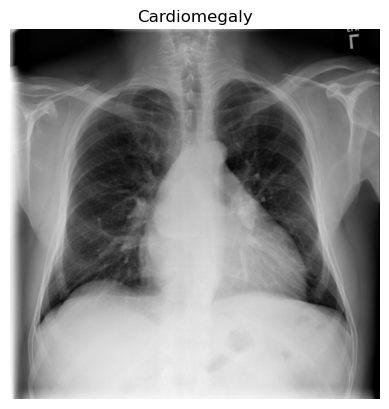

Image Index       00000001_000.png
Finding Labels        Cardiomegaly
Patient Gender                   M
Patient Age                     58
Name: 0, dtype: object


In [3]:
sample = subset.iloc[0]
img_path = f"../data/full_dataset/images/{sample['Image Index']}"

img = Image.open(img_path)

plt.imshow(img, cmap="gray")
plt.title(sample["Finding Labels"])
plt.axis("off")
plt.show()

print(sample[["Image Index", "Finding Labels", "Patient Gender", "Patient Age"]])

In [4]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

dataset = ChestXrayDataset(
    csv_file="../data/Data_Entry_2017.csv",
    image_dir="../data/full_dataset/images",
    transform=transform
)

print("Dataset size:", len(dataset))
print("Disease labels:", dataset.disease_columns)

image, disease_labels, gender_label = dataset[0]
print("Image shape:", image.shape)
print("Disease label shape:", disease_labels.shape)
print("Gender label:", gender_label)

Dataset size: 4999
Disease labels: ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax', 'Consolidation', 'Edema', 'Emphysema', 'Fibrosis', 'Pleural_Thickening', 'Hernia']
Image shape: torch.Size([3, 224, 224])
Disease label shape: torch.Size([14])
Gender label: tensor(1)


In [5]:
%%writefile ../src/xray_project/models.py
import torch.nn as nn
from torchvision.models import resnet18


class MultiTaskXRayModel(nn.Module):
    def __init__(self, num_diseases):
        super().__init__()

        self.backbone = resnet18(weights=None)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        self.disease_head = nn.Linear(in_features, num_diseases)
        self.gender_head = nn.Linear(in_features, 2)

    def forward(self, x):
        features = self.backbone(x)
        disease_logits = self.disease_head(features)
        gender_logits = self.gender_head(features)
        return disease_logits, gender_logits

Overwriting ../src/xray_project/models.py


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from pathlib import Path

from xray_project.models import MultiTaskXRayModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

model = MultiTaskXRayModel(num_diseases=len(dataset.disease_columns)).to(device)

disease_loss_fn = nn.BCEWithLogitsLoss()
gender_loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

for epoch in range(4):
    model.train()
    total_loss = 0

    for images, disease_labels, gender_labels in train_loader:
        images = images.to(device)
        disease_labels = disease_labels.to(device)
        gender_labels = gender_labels.to(device)

        optimizer.zero_grad()

        disease_logits, gender_logits = model(images)

        disease_loss = disease_loss_fn(disease_logits, disease_labels)
        gender_loss = gender_loss_fn(gender_logits, gender_labels)

        loss = disease_loss + gender_loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Train Loss: {total_loss / len(train_loader):.4f}")

Path("../outputs").mkdir(exist_ok=True)
torch.save(model.state_dict(), "../outputs/xray_multitask_model.pt")
print("Saved model to ../outputs/xray_multitask_model.pt")

Device: cuda
Epoch 1, Train Loss: 0.7841
Epoch 2, Train Loss: 0.5386
Epoch 3, Train Loss: 0.4299
Epoch 4, Train Loss: 0.3625
Saved model to ../outputs/xray_multitask_model.pt


In [7]:
model.eval()

total_gender = 0
correct_gender = 0
total_val_loss = 0

all_gender_preds = []
all_gender_true = []

with torch.no_grad():
    for images, disease_labels, gender_labels in val_loader:
        images = images.to(device)
        disease_labels = disease_labels.to(device)
        gender_labels = gender_labels.to(device)

        disease_logits, gender_logits = model(images)

        disease_loss = disease_loss_fn(disease_logits, disease_labels)
        gender_loss = gender_loss_fn(gender_logits, gender_labels)
        loss = disease_loss + gender_loss

        total_val_loss += loss.item()

        gender_preds = torch.argmax(gender_logits, dim=1)

        correct_gender += (gender_preds == gender_labels).sum().item()
        total_gender += gender_labels.size(0)

        all_gender_preds.extend(gender_preds.cpu().tolist())
        all_gender_true.extend(gender_labels.cpu().tolist())

val_loss = total_val_loss / len(val_loader)
gender_acc = correct_gender / total_gender

print("Validation Loss:", val_loss)
print("Gender Accuracy:", gender_acc)

Validation Loss: 0.44992202425759936
Gender Accuracy: 0.888


In [11]:
from sklearn.metrics import classification_report

print(classification_report(
    all_gender_true,
    all_gender_preds,
    target_names=["Female","Male"]
))

              precision    recall  f1-score   support

      Female       0.87      0.89      0.88       470
        Male       0.90      0.88      0.89       530

    accuracy                           0.89      1000
   macro avg       0.89      0.89      0.89      1000
weighted avg       0.89      0.89      0.89      1000



In [12]:
subset["Patient Gender"].value_counts(normalize=True)

Patient Gender
M    0.521704
F    0.478296
Name: proportion, dtype: float64

In [13]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_gender_true, all_gender_preds)
print(cm)

[[419  51]
 [ 61 469]]


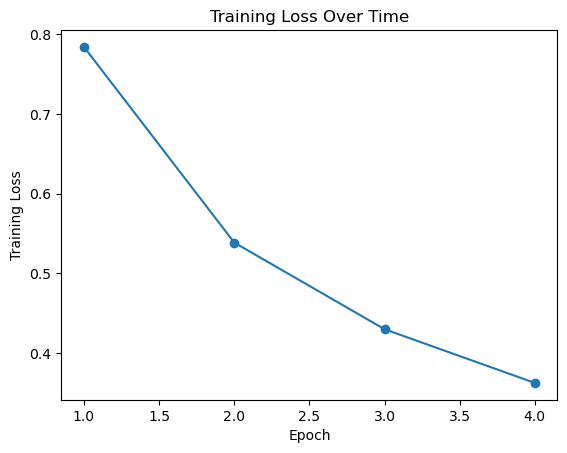

In [8]:
train_losses = [0.7841, 0.5386, 0.4299, 0.3625]

plt.figure()
plt.plot([1,2,3,4], train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Time")
plt.savefig("../outputs/training_loss.png", bbox_inches="tight")
plt.show()

In [9]:
import os
os.listdir("../outputs")

['train_metrics.txt',
 'xray_multitask_model.pt',
 'training_loss.png',
 '.gitkeep']

In [10]:
with open("../outputs/train_metrics.txt", "w") as f:
    f.write("Epoch 1 Train Loss: 0.7841\n")
    f.write("Epoch 2 Train Loss: 0.5386\n")
    f.write("Epoch 3 Train Loss: 0.4299\n")
    f.write("Epoch 4 Train Loss: 0.3625\n")
    f.write("Validation Loss: 0.4499\n")
    f.write("Gender Accuracy: 0.888\n")